<a href="https://colab.research.google.com/github/SimbakNetmind/series-de-tiempo/blob/M%C3%A9todos_para_Pron%C3%B3stico_y_Anal%C3%ADtica-Avanzada/01_M%C3%A9todos_de_suavizado_(SMA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Métodos de suavizado (SMA)

### Media móvil simple (SMA, *Simple Moving Average*)

* Suaviza la serie reemplazando cada valor por el promedio aritmético de los últimos $k$ valores observados.
* Reduce el ruido de corto plazo, pero **todos los valores del pasado reciente pesan igual**, sin distinguir qué tan nuevos son.

$$SMA_t = \frac{1}{k} \sum_{i=0}^{k-1} y_{t-i}$$

**Donde:**

* $y_{t-i}$: observaciones pasadas.
* $k$: orden de la media móvil que determina el nivel de suavizado.

---
# Métodos de suavizado (SMA) - Ejemplo práctico

### Fórmula de la Media Móvil Simple ($k=3$):

$$SMA_t = \frac{1}{k} \sum_{i=0}^{k-1} y_{t-i}$$

---

### Tabla de cálculos:

| Tiempo ($t$) | Dato ($y_t$) | Cálculo $k = 3$                   | SMA |
|:---:|:---:|:----------------------------------:|:---:|
| 1 | 10 | -                                  | -   |
| 2 | 12 | -                                  | -   |
| 3 | 13 | (13 + 12 + 10) / 3               | 11.67 |
| 4 | 16 | (16 + 13 + 12) / 3               | 13.67 |
| 5 | 15 | (15 + 16 + 13) / 3               | 14.67 |
| 6 | 20 | (20 + 15 + 16) / 3               | 17 |
| 7 | 22 | (22 + 20 + 15) / 3               | 19 |
| 8 | 21 | (21 + 22 + 20) / 3               | 21 |
| 9 | 23 | (23 + 21 + 22) / 3               | 22 |
| 10 | 25 |(25 + 23 + 21) / 3               | 23 |
| 11 | 26 |(26 + 25 + 23) / 3               | 24.67 |
| 12 | 28 |(28 + 26 + 25) / 3               | 26.33 |
| 13 | 30 |(30 + 28 + 26) / 3               | 28 |
| 14 | 29 |(29 + 30 + 28) / 3               | 29 |
| 15 | 31 |(31 + 29 + 30) / 3               | 30 |
| 16 | 33 |(33 + 31 + 29) / 3               | 31 |
| 17 | 35 |(35 + 33 + 31) / 3               | 33 |
| 18 | 36 |(36 + 35 + 33) / 3               | 34.67 |
| 19 | 38 |(38 + 36 + 35) / 3               | 36.33 |
| 20 | 42 |(42 + 38 + 36) / 3               | 38.67 |


---
## 📗 ***Instalación bibliotecas***

In [ ]:
!pip install numpy -q
!pip install pandas -q
!pip install matplotlib -q

## 🎯 ***Practica codigo (SMA)***

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#1. Media Móvil Simple (SMA)
k=3
# Serie de tiempo
data = [10, 12, 13, 16, 15, 20, 22, 21, 23, 25,
        26, 28, 30, 29, 31, 33, 35, 36, 38, 42]

df = pd.DataFrame({
    'Tiempo (t)': range(1, len(data) + 1),
    'Dato (yt)': data
})

# Generar columna de texto con formato
calculos = []
for i in range(len(data)):
    if i < k - 1:
        calculos.append("-")
    else:
        fórmula = f"({data[i]} + {data[i-1]} +{data[i-2]}) /{k}"
        calculos.append(fórmula)
df['Cálculo k = 3'] = calculos


# 2. Calculamos la media móvil simple (SMA)
sma_valores = df['Dato (yt)'].rolling(window=k).mean()



# 3. La formateamos para que los números tengan 1 decimal y los NaN sean "-"
df['SMA'] = sma_valores.apply(lambda x: f"{x:.1f}" if pd.notnull(x) else "-")

print(df.to_string(index=False, col_space=15, justify='center'))

   Tiempo (t)       Dato (yt)    Cálculo k = 3         SMA      
        1              10                      -          -     
        2              12                      -          -     
        3              13       (13 + 12 +10) /3       11.7     
        4              16       (16 + 13 +12) /3       13.7     
        5              15       (15 + 16 +13) /3       14.7     
        6              20       (20 + 15 +16) /3       17.0     
        7              22       (22 + 20 +15) /3       19.0     
        8              21       (21 + 22 +20) /3       21.0     
        9              23       (23 + 21 +22) /3       22.0     
       10              25       (25 + 23 +21) /3       23.0     
       11              26       (26 + 25 +23) /3       24.7     
       12              28       (28 + 26 +25) /3       26.3     
       13              30       (30 + 28 +26) /3       28.0     
       14              29       (29 + 30 +28) /3       29.0     
       15              31

---
## 📈 ***Grafica serie SMA vs Dato Reales***

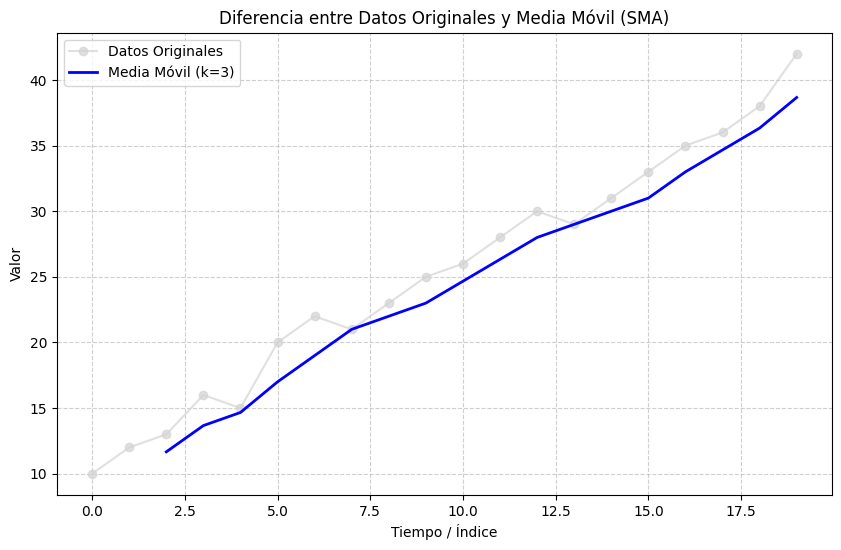

In [ ]:
# 4. Configuración de la gráfica
plt.figure(figsize=(10, 6))

# Graficamos los datos originales (puntos y línea fina)
plt.plot(df['Dato (yt)'], label='Datos Originales', marker='o', linestyle='-', color='lightgray', alpha=0.7)

# Graficamos la Media Móvil (línea más gruesa para notar la diferencia)
# Usamos sma_valores directamente que es numérico
plt.plot(sma_valores, label=f'Media Móvil (k={k})', color='blue', linewidth=2)

# Personalización
plt.title('Diferencia entre Datos Originales y Media Móvil (SMA)')
plt.xlabel('Tiempo / Índice')
plt.ylabel('Valor')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Mostrar
plt.show()